In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
print("Libraries imported successfully")

Libraries imported successfully


In [4]:
df = pd.read_csv("Titanic-Dataset.csv")

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.shape

(891, 12)

In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


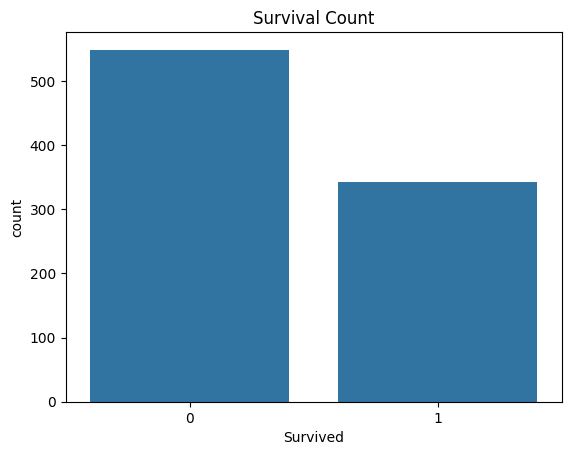

In [11]:
sns.countplot(
    x="Survived",
    data=df
)

plt.title("Survival Count")

plt.show()

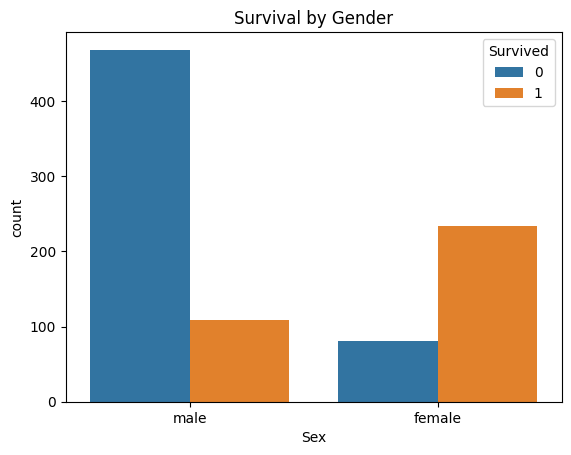

In [12]:
sns.countplot(
    x="Sex",
    hue="Survived",
    data=df
)

plt.title("Survival by Gender")

plt.show()

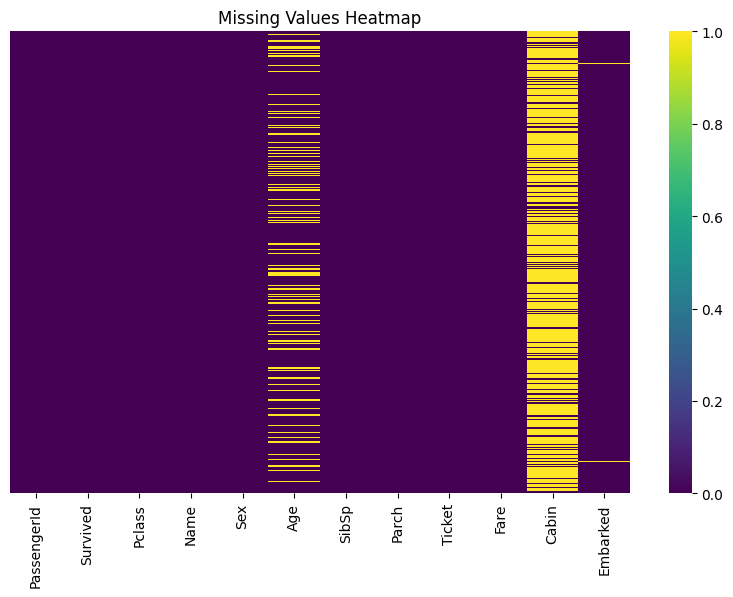

In [13]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.isnull(),
    yticklabels=False,
    cbar=True,
    cmap="viridis"
)

plt.title(
    "Missing Values Heatmap"
)

plt.show()

In [14]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [15]:
df.drop(
    columns=[
        "PassengerId",
        "Name",
        "Ticket",
        "Cabin"
    ],
    inplace=True
)

In [16]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [17]:
df["Age"] = df["Age"].fillna(
    df["Age"].median()
)

In [18]:
df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

In [19]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [20]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

In [21]:
df["Sex"] = encoder.fit_transform(
    df["Sex"]
)

In [22]:
df["Embarked"] = encoder.fit_transform(
    df["Embarked"]
)

In [23]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


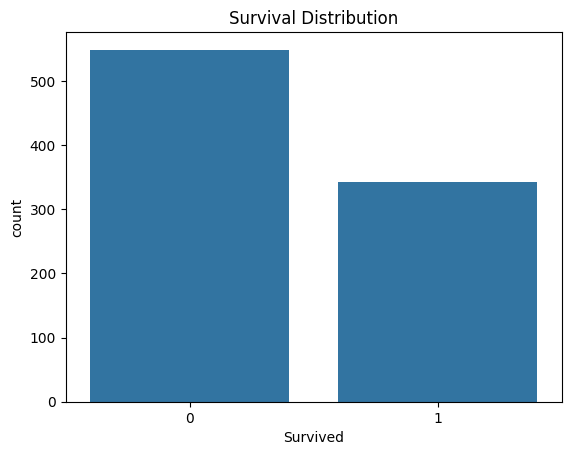

In [24]:
sns.countplot(
    x="Survived",
    data=df
)

plt.title(
    "Survival Distribution"
)

plt.show()

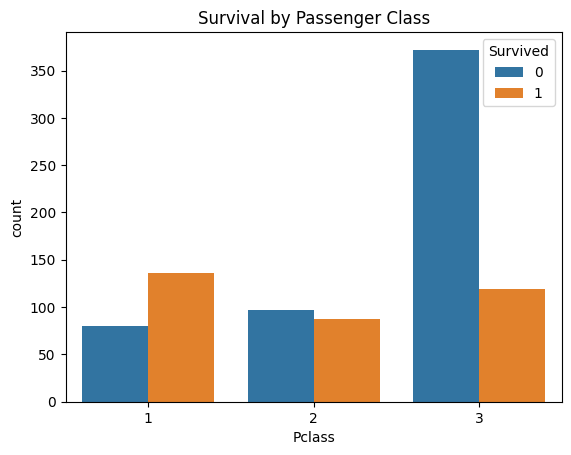

In [25]:
sns.countplot(
    x="Pclass",
    hue="Survived",
    data=df
)

plt.title(
    "Survival by Passenger Class"
)

plt.show()

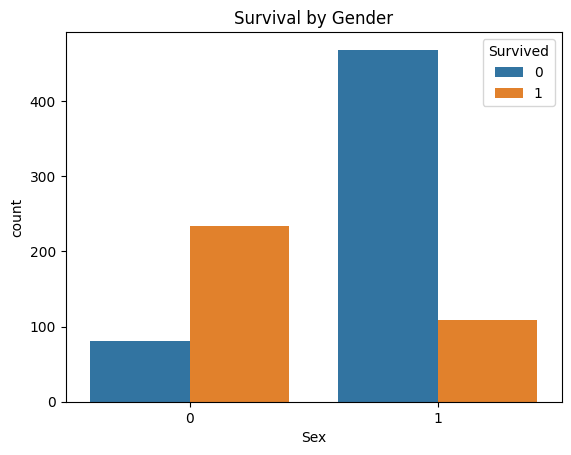

In [26]:
sns.countplot(
    x="Sex",
    hue="Survived",
    data=df
)

plt.title(
    "Survival by Gender"
)

plt.show()

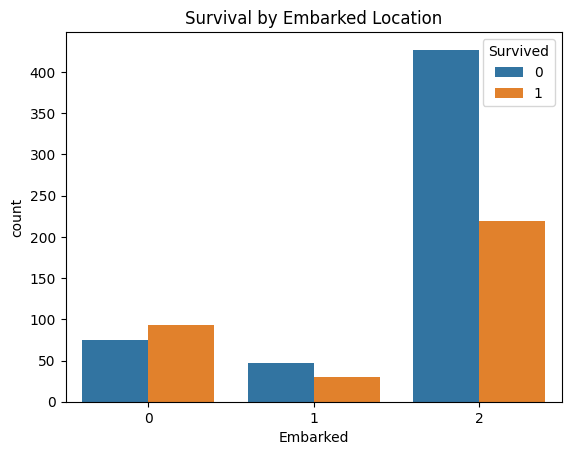

In [27]:
sns.countplot(
    x="Embarked",
    hue="Survived",
    data=df
)

plt.title(
    "Survival by Embarked Location"
)

plt.show()

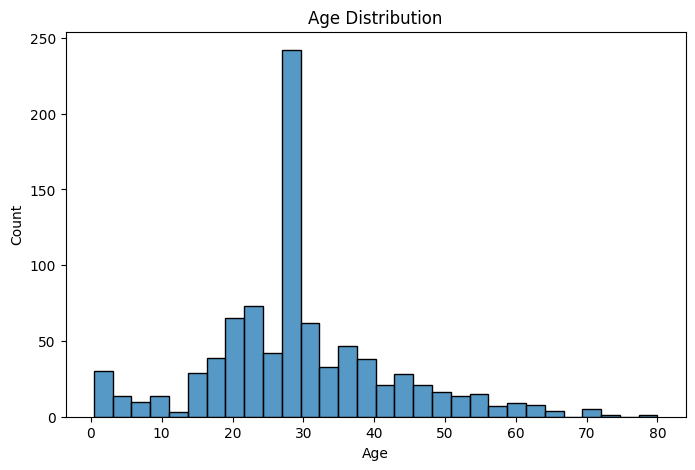

In [28]:
plt.figure(
    figsize=(8,5)
)

sns.histplot(
    df["Age"],
    bins=30
)

plt.title(
    "Age Distribution"
)

plt.show()

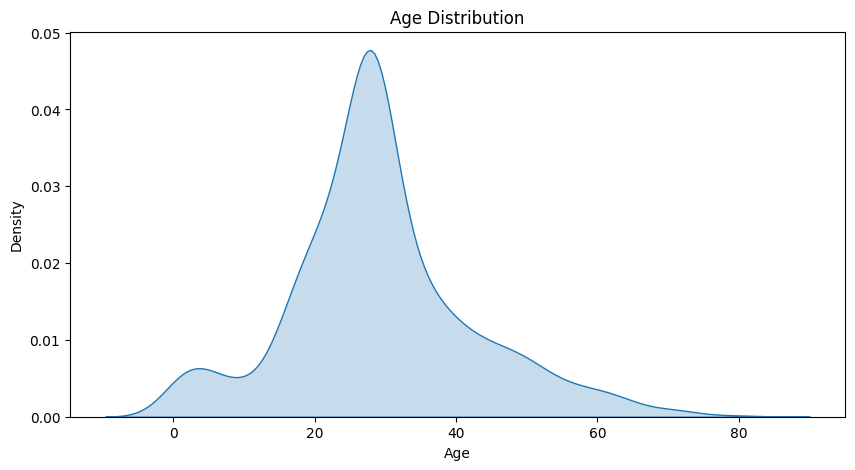

In [29]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    df["Age"],
    fill=True
)

plt.title(
    "Age Distribution"
)

plt.show()

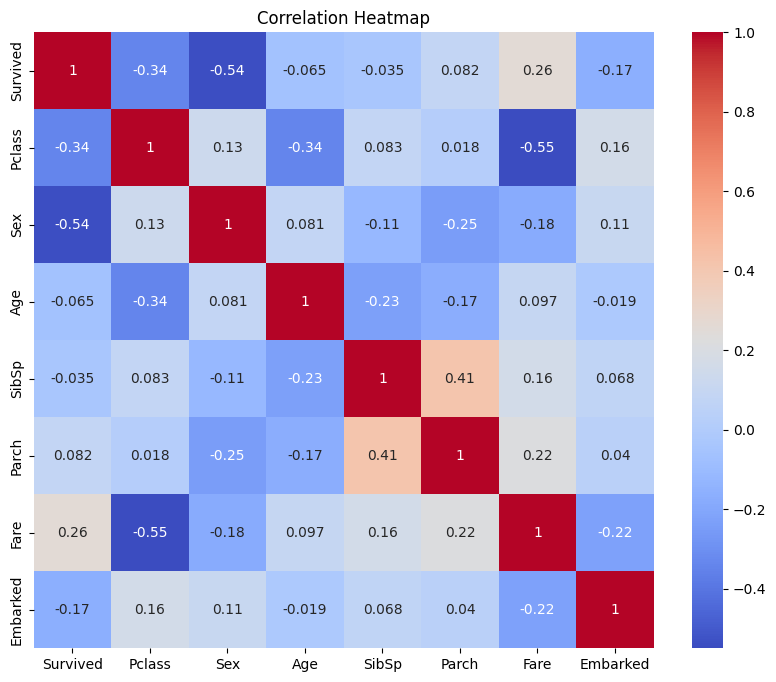

In [30]:
plt.figure(
    figsize=(10,8)
)

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

Observations:

1. Female passengers survived more.

2. First-class passengers had higher survival.

3. Age showed moderate impact.

4. Sex and Pclass appear important features.

In [31]:
X = df.drop(
    "Survived",
    axis=1
)

In [32]:
y = df["Survived"]

In [33]:
print(X.head())

   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0       3    1  22.0      1      0   7.2500         2
1       1    0  38.0      1      0  71.2833         0
2       3    0  26.0      0      0   7.9250         2
3       1    0  35.0      1      0  53.1000         2
4       3    1  35.0      0      0   8.0500         2


In [34]:
print(y.head())

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
print("Training:", X_train.shape)

print("Testing:", X_test.shape)

Training: (712, 7)
Testing: (179, 7)


In [37]:
model = LogisticRegression(
    max_iter=1000
)

In [38]:
model.fit(
    X_train,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [39]:
print(model)

LogisticRegression(max_iter=1000)


In [40]:
y_pred = model.predict(
    X_test
)

In [41]:
print(y_pred)

[0 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 1 1 0 0 0
 1 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 1 1
 0 0 1 1 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1
 0 1 0 1 0 0 0 1 0 0 1 1 0 0 1 1 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 1 1 0 1 0 0 0 1 1]


In [42]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
709,1,0
439,0,0
840,0,0
720,1,1
39,1,1
290,1,1
300,1,1
333,0,0
208,1,1
136,1,1


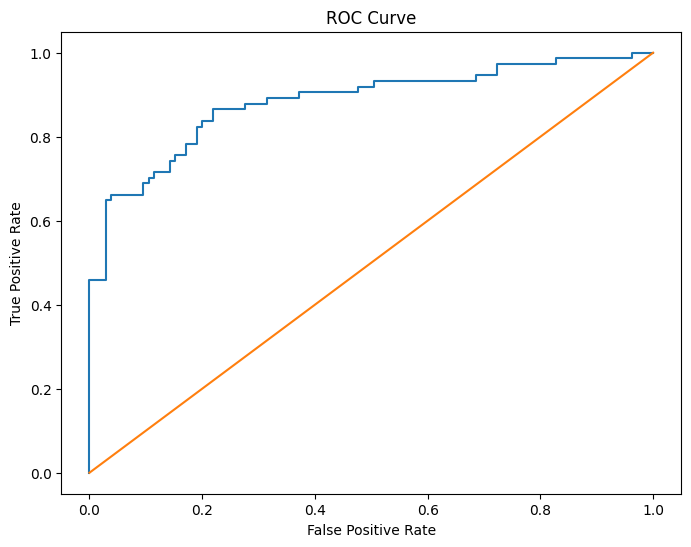

In [43]:
prob = model.predict_proba(
    X_test
)[:,1]

fpr,tpr,_ = roc_curve(
    y_test,
    prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr
)

plt.plot(
    [0,1],
    [0,1]
)

plt.title(
    "ROC Curve"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.show()

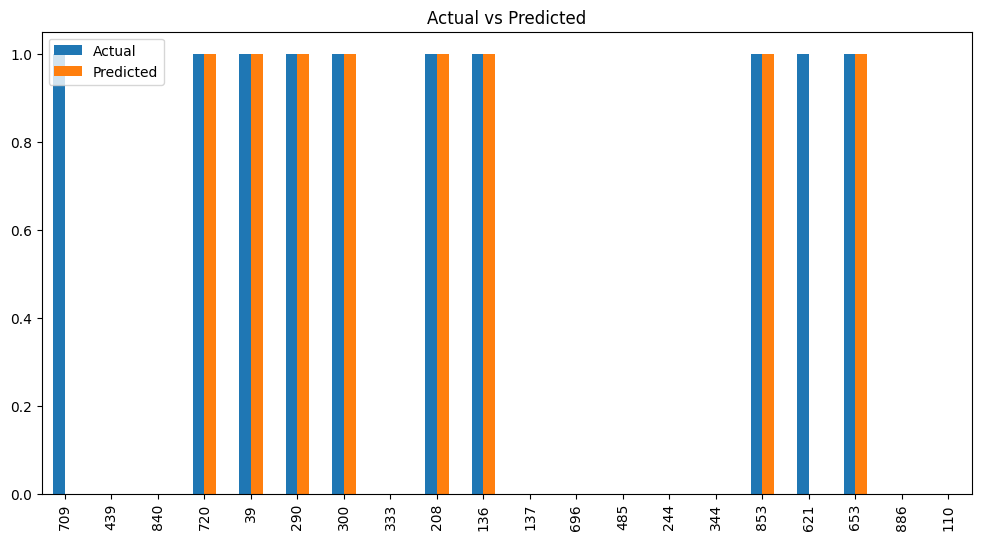

In [44]:
comparison.head(20).plot(
    kind="bar",
    figsize=(12,6)
)

plt.title(
    "Actual vs Predicted"
)

plt.show()

In [45]:
print(
comparison["Predicted"].value_counts()
)

Predicted
0    109
1     70
Name: count, dtype: int64


In [46]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    accuracy
)

Accuracy: 0.8100558659217877


In [47]:
print(
classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [48]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[90 15]
 [19 55]]


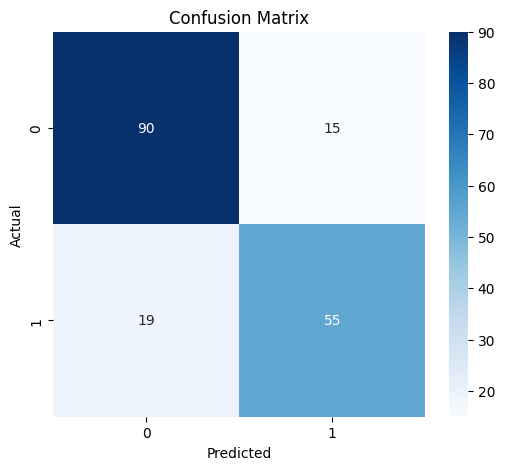

In [49]:
plt.figure(
    figsize=(6,5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

Model Evaluation:

1. Logistic Regression achieved good accuracy.

2. Confusion matrix shows majority predictions are correct.

3. Precision and Recall indicate balanced performance.

4. Model can predict Titanic survival effectively.

In [50]:
sample = [[
    3,      # Pclass
    1,      # Sex
    22,     # Age
    1,      # SibSp
    0,      # Parch
    7.25,   # Fare
    2       # Embarked
]]

In [51]:
prediction = model.predict(
    sample
)

print(prediction)

[0]


c:\Users\admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [52]:
if prediction[0]==1:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survive")

Passenger Did Not Survive


In [53]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance

,Feature,Coefficient
0,Pclass,-0.930680
1,Sex,-2.596995
2,Age,-0.030433
3,SibSp,-0.293905
4,Parch,-0.111852
5,Fare,0.002534
6,Embarked,-0.218777


In [54]:
importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

importance

,Feature,Coefficient
5,Fare,0.002534
2,Age,-0.030433
4,Parch,-0.111852
6,Embarked,-0.218777
3,SibSp,-0.293905
0,Pclass,-0.930680
1,Sex,-2.596995


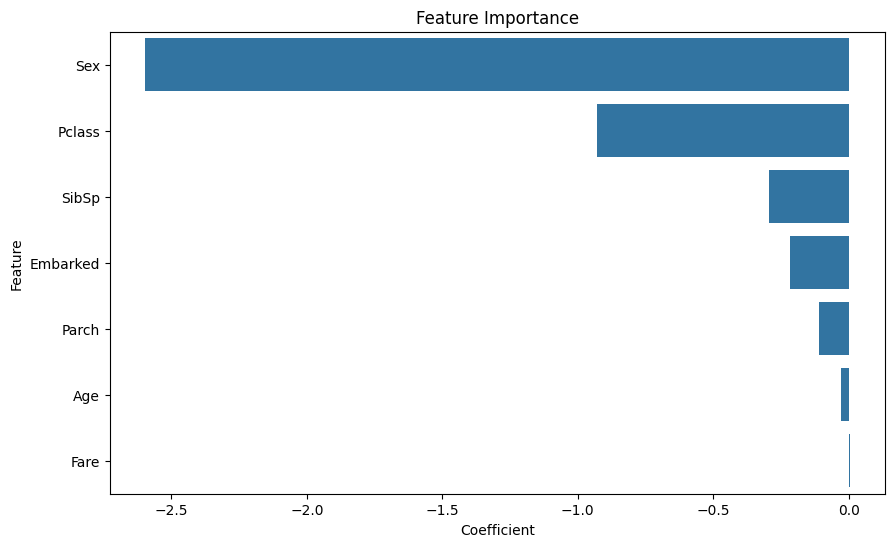

In [55]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance = importance.sort_values(
    by="Coefficient"
)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=importance
)

plt.title(
    "Feature Importance"
)

plt.show()

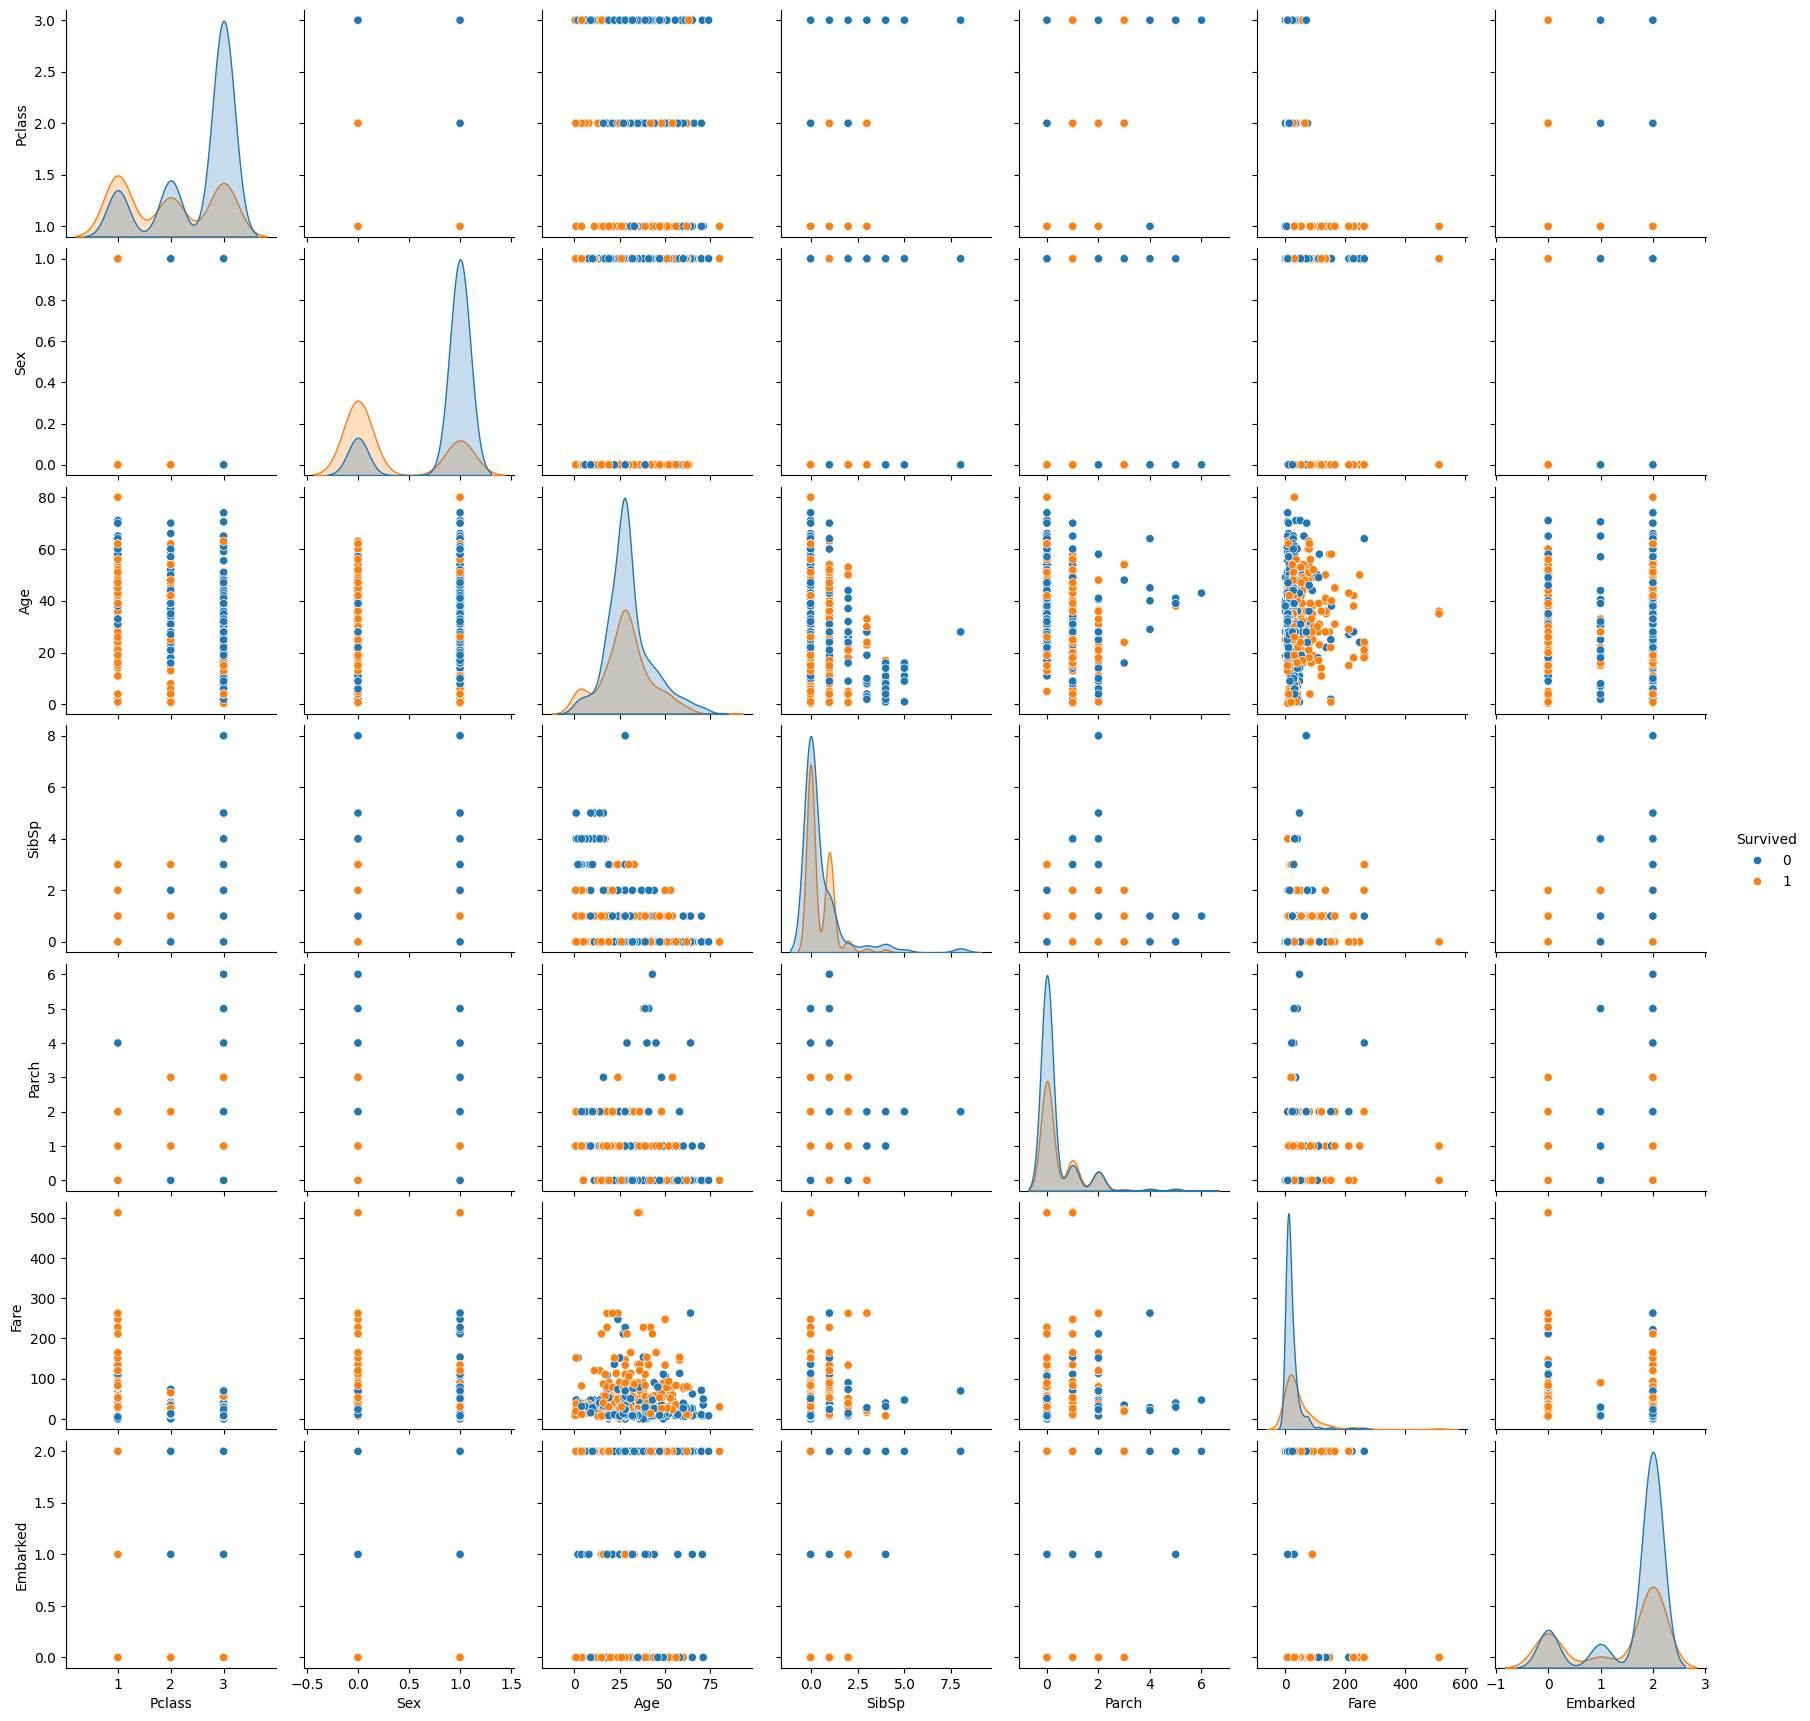

In [56]:
sns.pairplot(
    df,
    hue="Survived"
)

plt.show()

# Conclusion

This project predicts Titanic passenger survival using Machine Learning.

Steps performed:

1. Data Loading
2. Exploratory Data Analysis
3. Data Cleaning
4. Missing Value Handling
5. Feature Encoding
6. Model Training
7. Prediction
8. Evaluation

Model Used:
Logistic Regression

Result:
The model achieved good prediction performance and successfully classified passenger survival.